# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [1]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()

from visualization import *

In [3]:
# how to use base module:

# 1. Initilize Base model
# network = base.build_network(solve=False)  # just builds it

# 2. Edit/add components based on assignment details
# do some edits...

# 3. Solve model
# network.optimize(solver_name="highs")  # solve manually later

## F. Introducing ATC
Connect your country with, at least, two neighbouring countries. You can connect them using HVAC lines, HVDC links or gas pipelines. Use a linear representation of power flow or gas flow. 
You can assume that the generation capacities in the neighbouring countries are fixed or optimize the whole system. You can also include fixed interconnection capacities or optimize them with the generators' capacities. Discuss your results.

Add Lines with neighbouring countries

In [4]:
countries = ["DEU", "DNK", "NLD", "POL", "FRA", "AUT", "CHE", "CZE"]
coordinates = {
    'DEU': (51.15, 10.45),  # Germany (central)
    'DNK': (56.00, 10.00),  # Denmark
    'NLD': (52.30, 5.30),   # Netherlands
    'FRA': (46.60, 2.20),   # France
    'CHE': (47.00, 8.00),   # Switzerland
    'AUT': (47.50, 14.60),  # Austria
    'CZE': (49.80, 15.50),  # Czech Republic
    'POL': (52.10, 19.40)   # Poland
}

In [5]:
network = base.build_network(solve=False)

/Users/jonaswiendl/Documents/46770_IEG/46770_IEG/base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


In [6]:
df_elec, df_onshorewind, df_offhorewind, df_solar = base.load_time_series()
costs = base.load_technology_data()

for country in countries[1:]:
    # add demand 
    network.add("Bus",
                f"{country}_elec",
                y = coordinates[country][0],
                x = coordinates[country][1],
                carrier="AC")
    network.add("Load", 
                f"{country}_load",
                bus=f"{country}_elec",
                p_set=df_elec[country].values,
                carrier = "AC")
    network.add(
        "Generator",
        f"{country}_OCGT",
        bus=f"{country}_elec",
        carrier="OCGT",
        capital_cost=costs.at["OCGT", "capital_cost"],
        marginal_cost=costs.at["OCGT", "marginal_cost"],
        efficiency=costs.at["OCGT", "efficiency"],
        p_nom_extendable=True,
    )   
    CF_wind = df_onshorewind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
    network.add("Generator",
        f"{country}_onwind",
        bus=f"{country}_elec",
        carrier="onwind",
        capital_cost=costs.at["onwind", "capital_cost"],
        marginal_cost=costs.at["onwind", "marginal_cost"],
        p_max_pu=CF_wind.values,
        efficiency=costs.at["onwind", "efficiency"],
        p_nom_extendable=True,
    )
    CF_solar = df_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in network.snapshots]]
    network.add("Generator",
        f"{country}_solar",
        bus=f"{country}_elec",
        carrier="solar",
        capital_cost=costs.at["solar", "capital_cost"],
        marginal_cost=costs.at["solar", "marginal_cost"],
        p_max_pu=CF_solar.values,
        efficiency=costs.at["solar", "efficiency"],
        p_nom_extendable=True,
    )
    network.add(
        "Line",
        f"DEU-{country}",
        bus0="DEU_elec",
        bus1=f"{country}_elec",
        s_nom = 1000,
        x = 1,
        r = 1,
    )

In [7]:
network

Unnamed PyPSA Network
---------------------
Components:
 - Bus: 8
 - Carrier: 10
 - Generator: 29
 - Line: 7
 - Load: 8
Snapshots: 8760

/Users/jonaswiendl/anaconda3/envs/integrated-energy-grids/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x164e9d730>,
 <matplotlib.collections.LineCollection at 0x164da7350>)

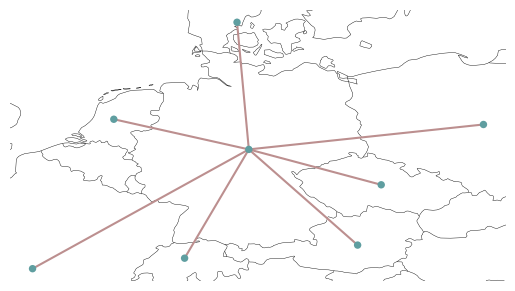

In [8]:
network.plot()

In [9]:
co2_constraint = False
if co2_constraint:
    co2_emissions_1990 = 366e6
    co2_allowance_2040 = 0.12*co2_emissions_1990
    co2_allowance_2040/10e6

    network.add("GlobalConstraint", "CO2Limit",
            carrier_attribute="co2_emissions",
            sense="<=",
            constant=co2_allowance_2040)
    print("CO2 constraint added")
else:
    print("no CO2 constraint implemented")

no CO2 constraint implemented


In [10]:
network.optimize(solver_name="highs")

Index(['DNK_load', 'NLD_load', 'POL_load', 'FRA_load', 'AUT_load', 'CHE_load',
       'CZE_load'],
      dtype='object', name='Load')
Index(['DEU_elec', 'DNK_elec', 'NLD_elec', 'POL_elec', 'FRA_elec', 'AUT_elec',
       'CHE_elec', 'CZE_elec'],
      dtype='object', name='Bus')
Index(['DEU-DNK', 'DEU-NLD', 'DEU-POL', 'DEU-FRA', 'DEU-AUT', 'DEU-CHE',
       'DEU-CZE'],
      dtype='object', name='Line')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 3/3 [00:00<00:00,  9.31it/s]
INFO:linopy.io: Writing time: 2.35s


Running HiGHS 1.9.0 (git hash: n/a): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [1e-03, 1e+00]
  Cost   [1e-02, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 9e+04]
Presolving model
324705 rows, 280934 cols, 851478 nonzeros  0s
317908 rows, 276686 cols, 888860 nonzeros  0s
Presolve : Reductions: rows 317908(-382926); columns 276686(-38703); elements 888860(-373202)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -8.8098608656e+06 Ph1: 87336(8.51132e+08); Du: 43536(10272.5) 1s
      60805     3.0758075058e+10 Pr: 67132(5.53769e+10); Du: 0(2.62433e-06) 6s
     161068     7.7739188439e+10 Pr: 31801(5.19239e+09); Du: 0(5.51206e-05) 11s
     205984     8.3252645572e+10 Pr: 65219(2.94014e+12); Du: 0(5.0191e-05) 16s
     239293     9.1945374007e+10 Pr: 28545(3.42941e+10); Du: 0(5.14383e-05) 22s
     243257     9.2946297235e+10 Pr: 28010(3.71844e+10); Du: 0(5.21116e-05)

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 315389 primals, 700834 duals
Objective: 9.65e+10
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper were not assigned to the network.


('ok', 'optimal')

In [12]:
# check some numbers

print(f"System cost: {round(network.objective / 1e9, 2)} billion euros")
print("")
print("Optimal Generator Capactities in GW:")
print(network.generators.p_nom_opt.div(1e3))  # MW -> GW
print("")
print("Optimal Energy Generation in GWh/a")
print(network.generators_t.p.sum().div(1e6))

# Total emissions in the system (sum over all generators and time)
actual_emissions = (
    network.generators_t.p
    .multiply(network.generators.carrier.map(network.carriers["co2_emissions"]))
    .sum()
    .sum()
)

print("")

if co2_constraint:
    # The imposed CO₂ limit (from GlobalConstraint)
    co2_limit = network.global_constraints.at["CO2Limit", "constant"]

    print(f"Actual emissions: {actual_emissions:.2e} t")
    print(f"CO₂ constraint  : {co2_limit:.2e} t")

    dual = network.global_constraints.at["CO2Limit", "mu"]
    print(f"Shadow price of CO₂: {dual:.2f} €/tCO2")

System cost: 95.92 billion euros

Optimal Generator Capactities in GW:
Generator
coal           -0.000000
lignite        30.000000
biomass CHP     5.000000
OCGT           35.890197
ror            -0.000000
onwind          0.041219
offwind        10.823105
solar          18.056954
DNK OCGT        5.918925
DNK_onwind      8.222314
DNK_solar      -0.000000
NLD OCGT       17.090991
NLD_onwind     18.838824
NLD_solar       9.196609
POL OCGT       20.481000
POL_onwind     32.000000
POL_solar      -0.000000
FRA OCGT       79.662944
FRA_onwind     99.078000
FRA_solar      42.358576
AUT OCGT       11.496045
AUT_onwind     12.198582
AUT_solar       3.018694
CHE OCGT       10.522000
CHE_onwind     -0.000000
CHE_solar      14.613402
CZE OCGT        9.998103
CZE_onwind      6.598913
CZE_solar       9.755503
Name: p_nom_opt, dtype: float64

Optimal Energy Generation in GWh/a
Generator
coal             0.000000
lignite        259.973484
biomass CHP     43.800000
OCGT           176.644686
ror         

In [13]:
# Average electricity price
network.buses_t.marginal_price.mean()

Bus
DEU_elec    67.639546
DNK_elec    60.814160
NLD_elec    66.744380
POL_elec    64.467921
FRA_elec    64.855793
AUT_elec    65.019689
CHE_elec    68.988998
CZE_elec    69.642319
dtype: float64

In [14]:
# Hours with almost zero price
network.buses_t.marginal_price[network.buses_t.marginal_price < 2].count()

Bus
DEU_elec       0
DNK_elec    1275
NLD_elec     523
POL_elec     843
FRA_elec     817
AUT_elec     739
CHE_elec     212
CZE_elec     110
dtype: int64

In [15]:
# Share of hours with almost zero price
(network.buses_t.marginal_price[network.buses_t.marginal_price < 2].count())/len(network.snapshots)

Bus
DEU_elec    0.000000
DNK_elec    0.145548
NLD_elec    0.059703
POL_elec    0.096233
FRA_elec    0.093265
AUT_elec    0.084361
CHE_elec    0.024201
CZE_elec    0.012557
dtype: float64

In [16]:
# Congestion rent
for country in countries[1:]:
    rent = ((network.buses_t.marginal_price["DEU_elec"] - network.buses_t.marginal_price[f"{country}_elec"]) * network.lines_t.p0[f"DEU-{country}"]).sum()
    print(f"DEU-{country}: {rent}")

DEU-DNK: -74439103.20198122
DEU-NLD: -50797939.46957867
DEU-POL: -146261972.8957308
DEU-FRA: -172906537.62490392
DEU-AUT: -68519906.84313104
DEU-CHE: -48493994.104028895
DEU-CZE: -43077226.18871142


In [17]:
# Utilisation of transmission line
network.lines_t.p0.abs().mean() / network.lines.s_nom_opt

Line
DEU-DNK    0.899890
DEU-NLD    0.968252
DEU-POL    0.971950
DEU-FRA    0.979411
DEU-AUT    0.951774
DEU-CHE    0.942159
DEU-CZE    0.960007
dtype: float64

In [18]:
# Total generation
network.generators_t.p.sum(axis=0).groupby([network.generators.bus, network.generators.carrier]).sum().div(1e6).round(1)

bus       carrier    
AUT_elec  OCGT            35.4
          onwind          26.8
          solar            3.3
CHE_elec  OCGT            42.8
          onwind           0.0
          solar           16.1
CZE_elec  OCGT            36.6
          onwind          11.4
          solar           10.3
DEU_elec  OCGT           176.6
          biomass CHP     43.8
          coal             0.0
          lignite        260.0
          offwind         34.1
          onwind           0.1
          ror              0.0
          solar           18.6
DNK_elec  OCGT            10.9
          onwind          19.7
          solar            0.0
FRA_elec  OCGT           219.4
          onwind         196.9
          solar           50.7
NLD_elec  OCGT            60.6
          onwind          38.4
          solar            9.5
POL_elec  OCGT            77.1
          onwind          68.5
          solar            0.0
dtype: float64